## Phonetic Mapping & Boundary RMSE
Using facebook/wav2vec2-base-960h for CTC forced alignment

Steps:
1. Load Wav2Vec2 model
2. Greedy CTC decode → character timestamps
3. Map chars to voiced/unvoiced
4. Compare against cepstrum boundaries
5. Compute RMSE

### 1. Imports & Load Audio

In [1]:
import numpy as np
import soundfile as sf
import torch
import torchaudio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC

file = "data/heisenberg.mp3"

sig, sr = sf.read(file)

if len(sig.shape) > 1:
    sig = sig.mean(axis=1)

sig = sig.astype(np.float32)

# wav2vec2 needs 16 kHz
if sr != 16000:
    t   = torch.tensor(sig).unsqueeze(0)
    sig = torchaudio.functional.resample(t, sr, 16000).squeeze().numpy()
    sr  = 16000

audio_len = len(sig) / sr
print(f"Audio: {audio_len:.2f} s  @ {sr} Hz")

Audio: 15.41 s  @ 16000 Hz


### 2. Load Wav2Vec2 Model

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model     = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-960h").to(device)
model.eval()

print("Model ready.")

Device: cuda


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model ready.


### 3. Forward Pass → Logits

In [3]:
inputs = processor(sig, sampling_rate=16000, return_tensors="pt", padding=True)

with torch.no_grad():
    logits = model(inputs.input_values.to(device)).logits

print("Logits shape:", logits.shape)

Logits shape: torch.Size([1, 770, 32])


### 4. Greedy CTC Decode with Timestamps

In [4]:
blank_id  = processor.tokenizer.pad_token_id
ids       = torch.argmax(logits, dim=-1)[0].cpu().numpy()
frame_dur = audio_len / len(ids)

char_segs = []
prev      = blank_id
seg_start = 0

for i, tid in enumerate(ids):
    if tid != prev:
        if prev != blank_id:
            ch = processor.tokenizer.convert_ids_to_tokens([prev])[0]
            char_segs.append({"char": ch, "start_sec": seg_start * frame_dur, "end_sec": i * frame_dur})
        seg_start = i
    prev = tid

if prev != blank_id:
    ch = processor.tokenizer.convert_ids_to_tokens([prev])[0]
    char_segs.append({"char": ch, "start_sec": seg_start * frame_dur, "end_sec": len(ids) * frame_dur})

transcript = "".join(s["char"] for s in char_segs).replace("|", " ").strip()
print("Transcript:", transcript)
print("Char segments:", len(char_segs))

Transcript: NOW SAY MY NAME ISEMBERG YOUR GOD DAMN WRIT
Char segments: 44


### 5. Map Characters → Voiced / Unvoiced
Vowels + voiced consonants → voiced. Everything else → unvoiced.

In [5]:
VOICED_CHARS = set("AEIOUYWLRMNBDGVZ")

def chars_to_vu(char_segs):
    merged = []
    for s in char_segs:
        c   = s["char"].strip().upper()
        lab = "voiced" if c in VOICED_CHARS else "unvoiced"
        if merged and merged[-1][2] == lab:
            merged[-1] = (merged[-1][0], s["end_sec"], lab)
        else:
            merged.append((s["start_sec"], s["end_sec"], lab))
    return merged

model_segs = chars_to_vu(char_segs)
print("Model V/UV segments:", len(model_segs))

Model V/UV segments: 20


### 6. Re-run Cepstrum Detection (same as voiced_unvoiced.py)

In [6]:
sig_full, sr_full = sf.read(file)
if len(sig_full.shape) > 1:
    sig_full = sig_full.mean(axis=1)
sig_full = sig_full.astype(np.float64)

alpha    = 0.97
frame_ms = 25.0
step_ms  = 10.0
NFFT     = 512

emph = np.append(sig_full[0], sig_full[1:] - alpha * sig_full[:-1])

fl = int(frame_ms * sr_full / 1000)
sl = int(step_ms  * sr_full / 1000)
nf = int((len(emph) - fl) / sl) + 1

pad_len = nf * sl + fl
padded  = np.zeros(pad_len)
padded[:len(emph)] = emph

frames   = np.array([padded[i*sl : i*sl+fl] for i in range(nf)])
frames_w = frames * np.hamming(fl)

def real_cepstrum(f, nfft=512):
    spec  = np.fft.rfft(f, n=nfft)
    log_s = np.log(np.abs(spec) + 1e-10)
    sym   = np.concatenate([log_s, log_s[-2:0:-1]])
    return np.real(np.fft.ifft(sym))

cepstrum = np.array([real_cepstrum(f, NFFT) for f in frames_w])

high_e  = np.max(np.abs(cepstrum[:, 20:101]), axis=1)
zcr_v   = np.array([np.sum(np.abs(np.diff(np.sign(f)))) / (2*len(f)) for f in frames])

thresh_h = np.median(high_e) + 0.5 * np.std(high_e)
voiced   = (high_e > thresh_h) & (zcr_v < 0.15)

times = np.arange(nf) * (step_ms/1000) + (frame_ms/1000)/2

manual_segs = []
cur  = voiced[0]
t0   = times[0]
for i in range(1, len(voiced)):
    if voiced[i] != cur:
        manual_segs.append((t0, times[i], "voiced" if cur else "unvoiced"))
        t0  = times[i]
        cur = voiced[i]
manual_segs.append((t0, times[-1], "voiced" if cur else "unvoiced"))

print("Manual V/UV segments:", len(manual_segs))

Manual V/UV segments: 41


### 7. Extract Boundaries & Compute RMSE

In [7]:
def get_bounds(segs):
    return np.array([s[1] for s in segs[:-1]])

manual_b = get_bounds(manual_segs)
model_b  = get_bounds(model_segs)

print("Manual boundaries:", len(manual_b))
print("Model  boundaries:", len(model_b))

# greedy nearest-neighbour matching, tolerance = 50 ms
tol   = 0.05
pairs = []
used  = set()

for mb in manual_b:
    dists = np.abs(model_b - mb)
    best  = int(np.argmin(dists))
    if dists[best] <= tol and best not in used:
        pairs.append((mb, model_b[best]))
        used.add(best)

if pairs:
    errors = np.array([abs(a - b) for a, b in pairs])
    rmse   = float(np.sqrt(np.mean(errors ** 2)))
else:
    errors = np.array([])
    rmse   = float("nan")

print(f"\nMatched pairs : {len(pairs)}")
print(f"Boundary RMSE : {rmse*1000:.2f} ms")

if pairs:
    print(f"\n{'Manual (s)':>10}  {'Model (s)':>10}  {'Error (ms)':>10}")
    print("-" * 36)
    for a, b in pairs:
        print(f"{a:10.3f}  {b:10.3f}  {abs(a-b)*1000:10.1f}")

Manual boundaries: 40
Model  boundaries: 19

Matched pairs : 7
Boundary RMSE : 29.93 ms

Manual (s)   Model (s)  Error (ms)
------------------------------------
     0.632       0.680        47.9
     2.833       2.821        11.0
     2.863       2.902        39.0
     3.233       3.262        29.2
    14.182      14.167        15.1
    14.522      14.548        25.1
    14.582      14.608        25.1


### 8. Alignment Plot

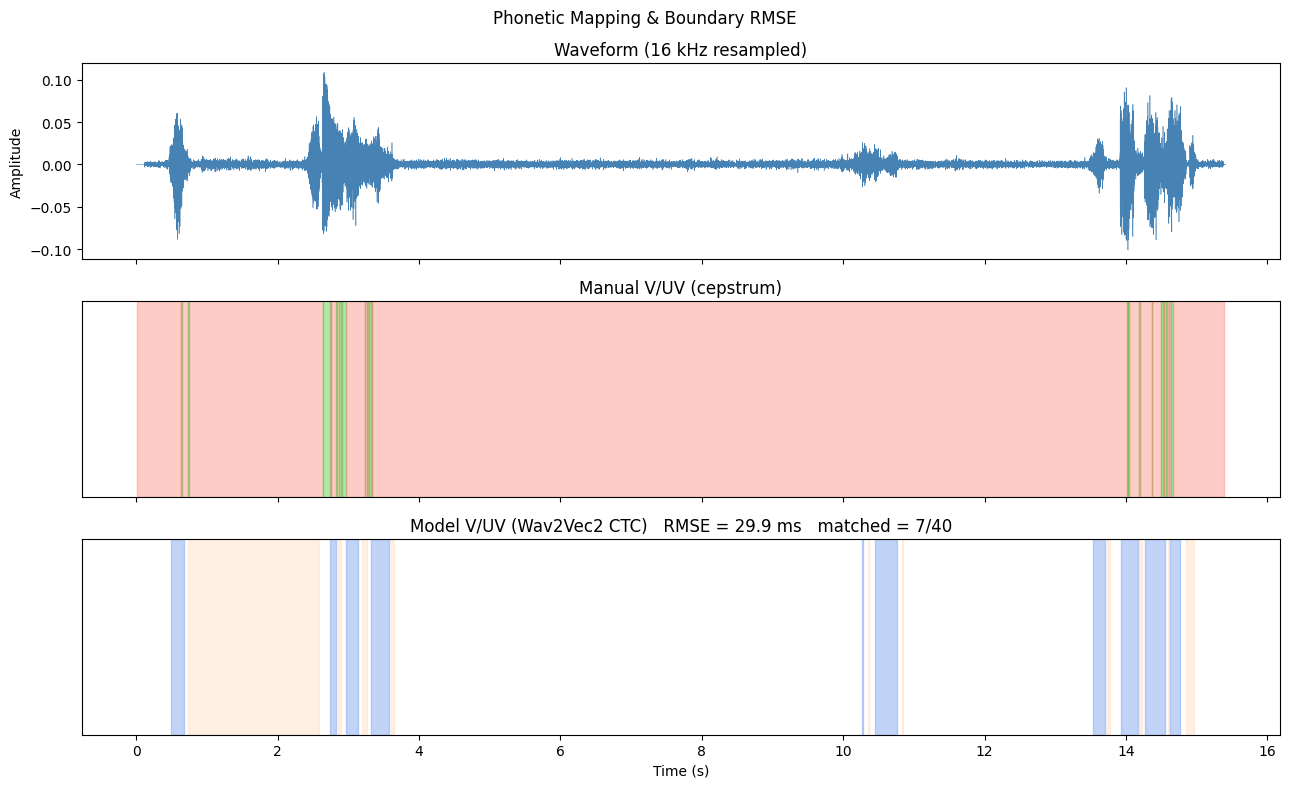

In [8]:
t_wav = np.arange(len(sig)) / sr

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

axes[0].plot(t_wav, sig, lw=0.4, color="steelblue")
axes[0].set(title="Waveform (16 kHz resampled)", ylabel="Amplitude")

for s, e, lab in manual_segs:
    c = "limegreen" if lab == "voiced" else "salmon"
    axes[1].axvspan(s, e, alpha=0.4, color=c)
axes[1].set(title="Manual V/UV (cepstrum)")
axes[1].set_yticks([])

for s, e, lab in model_segs:
    c = "cornflowerblue" if lab == "voiced" else "peachpuff"
    axes[2].axvspan(s, e, alpha=0.4, color=c)
axes[2].set(
    title=f"Model V/UV (Wav2Vec2 CTC)   RMSE = {rmse*1000:.1f} ms   matched = {len(pairs)}/{len(manual_b)}",
    xlabel="Time (s)"
)
axes[2].set_yticks([])

plt.suptitle("Phonetic Mapping & Boundary RMSE", fontsize=12)
plt.tight_layout()
plt.savefig("alignment.png", dpi=150)
plt.show()